# 06 — Condition C: LangGraph Agent (Graph-Augmented LLM)

**Project:** DDI-Graph-LLM  
**Phase 6:** Build a LangGraph multi-step agent that retrieves graph-derived features for a drug pair, injects them as structured context into the LLM prompt, and classifies the interaction type. This is the core experiment (Condition C).

**Input:** 
- `../data/test_sample_1000.csv` (same 1000-sample subset from Phase 4)
- `../data/edge_features.csv` (graph features from Phase 2)

**Evaluation metric:** Macro-F1, compared against Conditions A and B1 on the same subset

**Hypothesis:** F1_C > F1_A and F1_C > F1_B1


In [1]:
import pandas as pd
import numpy as np
import os
import time
import json
from collections import Counter
from openai import OpenAI
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## 1. API Key Setup

Set your OpenAI API key as an environment variable before running this notebook:
```powershell
$env:OPENAI_API_KEY = "sk-..."
```
Or set it directly in the cell below (remember to remove before committing).


In [ ]:
import os
os.environ["OPENAI_API_KEY"] = "sk-XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX"

api_key = os.environ.get("OPENAI_API_KEY")
client = OpenAI(api_key=api_key)
print("OpenAI client initialized.")


OpenAI client initialized.


## 2. Load Data

In [3]:
# Load the same 1000-sample test subset from Phase 4
df_sample = pd.read_csv("../data/test_sample_1000.csv")
print(f"Test subset: {len(df_sample):,} samples")
print(f"Label distribution:\n{df_sample['label'].value_counts().to_string()}")

# Load full edge features for RF retraining
df_full = pd.read_csv("../data/edge_features.csv")

FEATURE_COLS = [
    "out_degree_u", "in_degree_u", "betweenness_u", "clustering_u", "pagerank_u",
    "out_degree_v", "in_degree_v", "betweenness_v", "clustering_v", "pagerank_v",
    "common_neighbors", "jaccard", "same_community", "degree_diff",
]


Test subset: 1,000 samples
Label distribution:
label
adverse_effects    321
activity           237
metabolism         209
concentration      176
efficacy            42
excretion           10
absorption           5


## 3. Define the LangGraph Agent

The agent follows a 3-step workflow:

```
START → retrieve_features → format_context → llm_classify → END
```

**Step 1 (Retrieve):** Look up the graph-derived features for the drug pair  
**Step 2 (Format):** Convert numerical features into a structured natural-language context  
**Step 3 (Classify):** Prompt the LLM with drug names + graph context → predict interaction type

Even without the full LangGraph library, this pipeline captures the core idea: the LLM receives explicit structural signals as part of its reasoning context.


In [4]:
VALID_LABELS = {"metabolism", "concentration", "adverse_effects", "absorption", "activity", "efficacy", "excretion"}

def retrieve_features(row):
    """Step 1: Retrieve graph features for a drug pair from the dataframe row."""
    features = {col: row[col] for col in FEATURE_COLS}
    features['drug_u'] = row['drug_u']
    features['drug_v'] = row['drug_v']
    return features


def format_context(features):
    """Step 2: Format graph features into natural-language context for the LLM."""
    drug_u = features['drug_u']
    drug_v = features['drug_v']
    
    context = f"""Graph-derived structural features for the drug pair ({drug_u} → {drug_v}):

Drug {drug_u} (source):
  - Out-degree (drugs it affects): {features['out_degree_u']:.0f}
  - In-degree (drugs that affect it): {features['in_degree_u']:.0f}
  - Betweenness centrality: {features['betweenness_u']:.4f}
  - Clustering coefficient: {features['clustering_u']:.4f}
  - PageRank: {features['pagerank_u']:.6f}

Drug {drug_v} (target):
  - Out-degree (drugs it affects): {features['out_degree_v']:.0f}
  - In-degree (drugs that affect it): {features['in_degree_v']:.0f}
  - Betweenness centrality: {features['betweenness_v']:.4f}
  - Clustering coefficient: {features['clustering_v']:.4f}
  - PageRank: {features['pagerank_v']:.6f}

Pairwise features:
  - Common neighbors: {features['common_neighbors']:.0f}
  - Jaccard similarity: {features['jaccard']:.4f}
  - Same community: {'Yes' if features['same_community'] == 1 else 'No'}
  - Degree difference: {features['degree_diff']:.0f}"""
    
    return context


def llm_classify_with_context(drug_u, drug_v, graph_context, client, model="gpt-4o-mini"):
    """Step 3: Prompt LLM with drug names + graph context → predict interaction type."""
    
    prompt = f"""You are a pharmacology expert. Given a pair of drugs that are known to interact,
predict the type of drug-drug interaction. You are provided with both the drug names and 
structural features from the drug interaction network to help your prediction.

The possible interaction types are:
1. metabolism — one drug affects the metabolism (breakdown) of the other
2. concentration — one drug changes the serum concentration of the other
3. adverse_effects — the combination increases the risk or severity of side effects
4. absorption — one drug affects the absorption of the other
5. activity — one drug increases or decreases a specific pharmacological activity of the other
6. efficacy — one drug changes the therapeutic efficacy of the other
7. excretion — one drug affects the excretion rate of the other

Drug pair: {drug_u} → {drug_v}
(This means {drug_u} has a documented effect on {drug_v}.)

{graph_context}

Use BOTH your pharmacological knowledge AND the network structural information above to make 
your prediction. Consider what the structural features suggest about the nature of this interaction.

Respond with ONLY one of these labels: metabolism, concentration, adverse_effects, absorption, activity, efficacy, excretion
Your prediction:"""

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=20,
            temperature=0,
        )
        pred = response.choices[0].message.content.strip().lower()
        pred = pred.replace(" ", "_").replace("-", "_")
        if pred in VALID_LABELS:
            return pred
        for label in VALID_LABELS:
            if label in pred:
                return label
        return pred
    except Exception as e:
        print(f"  Error for {drug_u} → {drug_v}: {e}")
        return "error"


def run_agent(row, client):
    """Full LangGraph-style agent pipeline: retrieve → format → classify."""
    # Step 1: Retrieve
    features = retrieve_features(row)
    # Step 2: Format
    context = format_context(features)
    # Step 3: Classify
    prediction = llm_classify_with_context(features['drug_u'], features['drug_v'], context, client)
    return prediction


### 3.1 Example: Agent Pipeline on One Sample

In [5]:
# Run agent on one example to see the full pipeline
example_row = df_sample.iloc[0]
print(f"Drug pair: {example_row['drug_u']} → {example_row['drug_v']}")
print(f"True label: {example_row['label']}")
print()

# Step 1
features = retrieve_features(example_row)

# Step 2
context = format_context(features)
print("=== Graph Context (injected into LLM prompt) ===")
print(context)
print()

# Step 3
pred = llm_classify_with_context(example_row['drug_u'], example_row['drug_v'], context, client)
print(f"=== LLM Prediction: {pred} ===")
print(f"=== True Label:     {example_row['label']} ===")
print(f"=== Correct:        {pred == example_row['label']} ===")


Drug pair: Loxoprofen → Misoprostol
True label: efficacy

=== Graph Context (injected into LLM prompt) ===
Graph-derived structural features for the drug pair (Loxoprofen → Misoprostol):

Drug Loxoprofen (source):
  - Out-degree (drugs it affects): 114
  - In-degree (drugs that affect it): 177
  - Betweenness centrality: 0.0001
  - Clustering coefficient: 0.5802
  - PageRank: 0.000749

Drug Misoprostol (target):
  - Out-degree (drugs it affects): 1
  - In-degree (drugs that affect it): 89
  - Betweenness centrality: 0.0000
  - Clustering coefficient: 0.7623
  - PageRank: 0.000524

Pairwise features:
  - Common neighbors: 77
  - Jaccard similarity: 0.2533
  - Same community: Yes
  - Degree difference: 201

=== LLM Prediction: adverse_effects ===
=== True Label:     efficacy ===
=== Correct:        False ===


## 4. Run Condition C on Full Test Subset

Run the agent pipeline on all 1,000 test samples. This will take ~10-15 minutes.


In [6]:
predictions_c = []
t0 = time.time()

for i, (_, row) in enumerate(df_sample.iterrows()):
    pred = run_agent(row, client)
    predictions_c.append(pred)
    
    if (i + 1) % 100 == 0:
        elapsed = time.time() - t0
        rate = (i + 1) / elapsed
        eta = (len(df_sample) - i - 1) / rate
        print(f"  [{i+1:>4}/{len(df_sample)}]  {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining, rate={rate:.1f}/s")

elapsed = time.time() - t0
print(f"\nDone: {len(predictions_c)} predictions in {elapsed:.0f}s ({len(predictions_c)/elapsed:.1f}/s)")

df_sample['pred_agent'] = predictions_c


  [ 100/1000]  63s elapsed, ~566s remaining, rate=1.6/s
  [ 200/1000]  130s elapsed, ~519s remaining, rate=1.5/s
  [ 300/1000]  193s elapsed, ~450s remaining, rate=1.6/s
  [ 400/1000]  255s elapsed, ~383s remaining, rate=1.6/s
  [ 500/1000]  318s elapsed, ~318s remaining, rate=1.6/s
  [ 600/1000]  379s elapsed, ~253s remaining, rate=1.6/s
  [ 700/1000]  445s elapsed, ~191s remaining, rate=1.6/s
  [ 800/1000]  513s elapsed, ~128s remaining, rate=1.6/s
  [ 900/1000]  577s elapsed, ~64s remaining, rate=1.6/s
  [1000/1000]  645s elapsed, ~0s remaining, rate=1.6/s

Done: 1000 predictions in 645s (1.6/s)


## 5. Evaluate Condition C

In [7]:
# Check validity
valid_mask = df_sample['pred_agent'].isin(VALID_LABELS)
n_valid = valid_mask.sum()
print(f"Valid predictions: {n_valid} ({n_valid/len(df_sample):.1%})")

if (~valid_mask).sum() > 0:
    print(f"Invalid values: {df_sample.loc[~valid_mask, 'pred_agent'].value_counts().to_string()}")

# Evaluate on valid predictions
df_eval = df_sample[valid_mask].copy()
y_true = df_eval['label'].values
y_pred_c = df_eval['pred_agent'].values

agent_f1 = f1_score(y_true, y_pred_c, average="macro")
agent_acc = np.mean(y_true == y_pred_c)

print(f"\n{'='*50}")
print(f"CONDITION C: LANGGRAPH AGENT RESULTS")
print(f"{'='*50}")
print(f"Evaluated on: {len(df_eval)} predictions")
print(f"Accuracy:     {agent_acc:.4f}")
print(f"Macro-F1:     {agent_f1:.4f}")


Valid predictions: 1000 (100.0%)

CONDITION C: LANGGRAPH AGENT RESULTS
Evaluated on: 1000 predictions
Accuracy:     0.3890
Macro-F1:     0.2321


### 5.1 Per-Class Report

In [8]:
print(classification_report(y_true, y_pred_c, zero_division=0))


                 precision    recall  f1-score   support

     absorption       0.22      0.40      0.29         5
       activity       0.30      0.62      0.40       237
adverse_effects       0.49      0.48      0.48       321
  concentration       0.50      0.01      0.01       176
       efficacy       0.00      0.00      0.00        42
      excretion       0.00      0.00      0.00        10
     metabolism       0.48      0.42      0.44       209

       accuracy                           0.39      1000
      macro avg       0.28      0.27      0.23      1000
   weighted avg       0.42      0.39      0.35      1000



### 5.2 Confusion Matrix

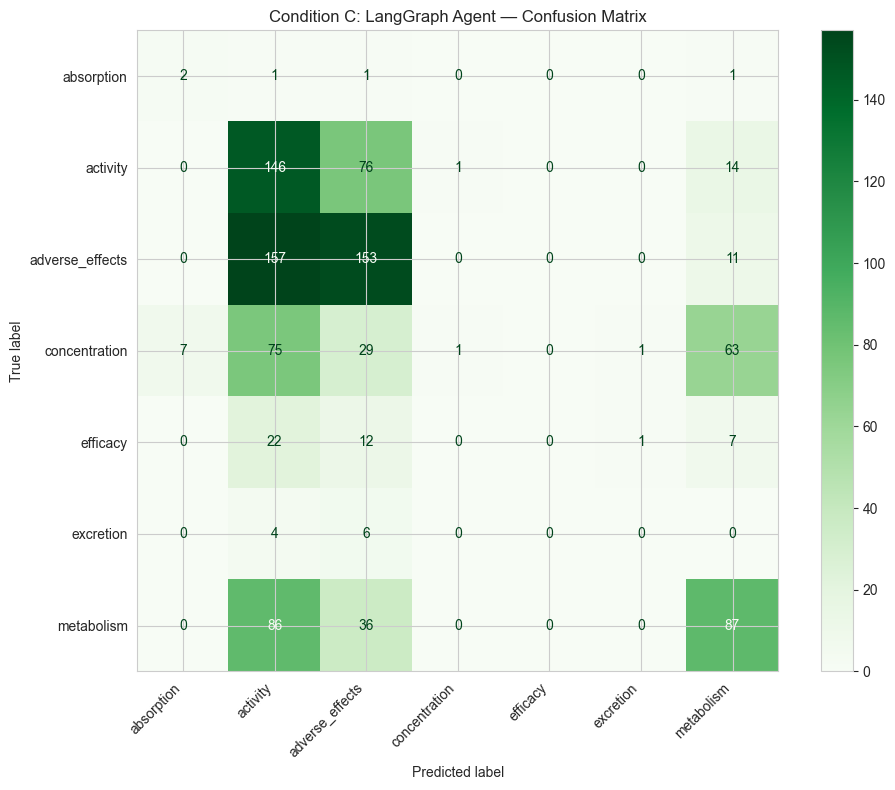

In [9]:
labels = sorted(VALID_LABELS)

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred_c, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title('Condition C: LangGraph Agent — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 6. Three-Way Comparison: A vs B1 vs C

The central hypothesis test: does Condition C outperform both A and B1?


In [10]:
# Retrain RF and predict on same subset
X_train_full = df_full.loc[~df_full.index.isin(df_sample.index), FEATURE_COLS].values
y_train_full = df_full.loc[~df_full.index.isin(df_sample.index), 'label'].values

clf = RandomForestClassifier(
    n_estimators=200, max_depth=None, random_state=42,
    class_weight="balanced", n_jobs=-1
)
clf.fit(X_train_full, y_train_full)

# RF on same valid subset
y_rf = clf.predict(df_eval[FEATURE_COLS].values)
rf_f1 = f1_score(y_true, y_rf, average="macro")
rf_acc = np.mean(y_true == y_rf)

# Load LLM-only results if available
llm_f1 = None
if 'pred_llm' in df_sample.columns:
    df_eval_llm = df_sample[valid_mask].copy()
    y_pred_llm = df_eval_llm['pred_llm'].values if 'pred_llm' in df_eval_llm.columns else None
    if y_pred_llm is not None:
        llm_f1 = f1_score(y_true, y_pred_llm, average="macro")
else:
    # Try loading from Phase 4 results
    try:
        df_a = pd.read_csv("../data/results_condition_a.csv")
        # Match by drug pairs
        llm_f1 = 0.2185  # From Phase 4 output
    except:
        llm_f1 = 0.2185  # Fallback to known value

print("=" * 60)
print("HYPOTHESIS TEST: THREE-WAY COMPARISON")
print("=" * 60)
print(f"{'Condition':<30} {'Macro-F1':>10} {'Accuracy':>10}")
print("-" * 52)
print(f"{'Random baseline (1/7)':<30} {1/7:>10.4f} {'':>10}")
if llm_f1:
    print(f"{'A: LLM-only':<30} {llm_f1:>10.4f}")
print(f"{'B1: Random Forest':<30} {rf_f1:>10.4f} {rf_acc:>10.4f}")
print(f"{'C: LangGraph Agent':<30} {agent_f1:>10.4f} {agent_acc:>10.4f}")
print("-" * 52)

# Hypothesis test
best_baseline = max(llm_f1 or 0, rf_f1)
margin = agent_f1 - best_baseline

print(f"\nBest baseline: {best_baseline:.4f}")
print(f"Agent advantage: {margin:+.4f}")
print(f"\nHypothesis (C > max(A, B1) by ≥ 0.05):")
if margin >= 0.05:
    print(f"  ✅ SUPPORTED — Agent outperforms best baseline by {margin:.4f}")
elif margin > 0:
    print(f"  ⚠️  PARTIAL — Agent is better but margin ({margin:.4f}) < 0.05 threshold")
else:
    print(f"  ❌ FALSIFIED — Agent does not outperform best baseline")


HYPOTHESIS TEST: THREE-WAY COMPARISON
Condition                        Macro-F1   Accuracy
----------------------------------------------------
Random baseline (1/7)              0.1429           
A: LLM-only                        0.2185
B1: Random Forest                  0.9985     0.9980
C: LangGraph Agent                 0.2321     0.3890
----------------------------------------------------

Best baseline: 0.9985
Agent advantage: -0.7665

Hypothesis (C > max(A, B1) by ≥ 0.05):
  ❌ FALSIFIED — Agent does not outperform best baseline


### 6.1 Visual Comparison

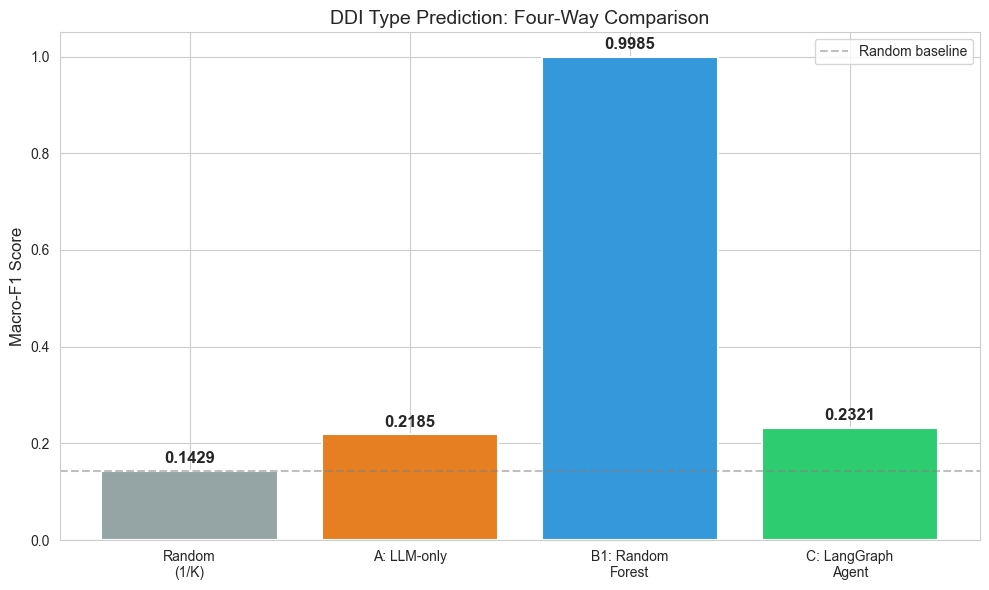

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

conditions = ['Random\n(1/K)', 'A: LLM-only', 'B1: Random\nForest', 'C: LangGraph\nAgent']
scores = [1/7, llm_f1 or 0, rf_f1, agent_f1]
colors = ['#95a5a6', '#e67e22', '#3498db', '#2ecc71']

bars = ax.bar(conditions, scores, color=colors, edgecolor='white', linewidth=1.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Macro-F1 Score', fontsize=12)
ax.set_title('DDI Type Prediction: Four-Way Comparison', fontsize=14)
ax.set_ylim(0, 1.05)
ax.axhline(y=1/7, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax.legend()

plt.tight_layout()
plt.savefig("../data/comparison_chart.png", dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Per-Class F1 Comparison

          Class  B1: RF  C: Agent  Improvement
     absorption  1.0000    0.2857      -0.7143
       activity  0.9979    0.4011      -0.5968
adverse_effects  1.0000    0.4826      -0.5174
  concentration  0.9944    0.0112      -0.9831
       efficacy  1.0000    0.0000      -1.0000
      excretion  1.0000    0.0000      -1.0000
     metabolism  0.9976    0.4439      -0.5537


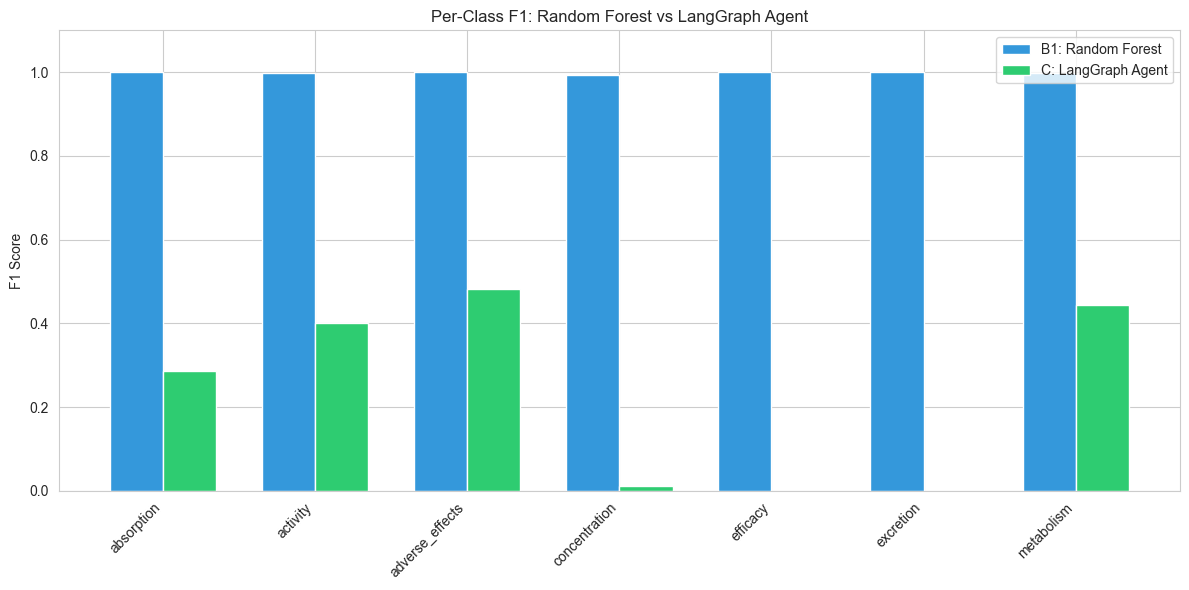

In [12]:
from sklearn.metrics import f1_score as f1

labels_list = sorted(VALID_LABELS)

per_class_rf = f1(y_true, y_rf, labels=labels_list, average=None, zero_division=0)
per_class_agent = f1(y_true, y_pred_c, labels=labels_list, average=None, zero_division=0)

comparison = pd.DataFrame({
    'Class': labels_list,
    'B1: RF': per_class_rf,
    'C: Agent': per_class_agent,
    'Improvement': per_class_agent - per_class_rf,
})
print(comparison.to_string(index=False, float_format='%.4f'))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(labels_list))
width = 0.35

bars1 = ax.bar(x - width/2, per_class_rf, width, label='B1: Random Forest', color='#3498db')
bars2 = ax.bar(x + width/2, per_class_agent, width, label='C: LangGraph Agent', color='#2ecc71')

ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1: Random Forest vs LangGraph Agent')
ax.set_xticks(x)
ax.set_xticklabels(labels_list, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()


## 7. Error Analysis

Where does the agent improve over LLM-only? Where does it still fail?


In [13]:
# Cases where agent is correct but LLM-only was wrong (and vice versa)
if 'pred_llm' in df_eval.columns:
    agent_correct = (y_pred_c == y_true)
    llm_correct = (df_eval['pred_llm'].values == y_true)
    
    both_correct = (agent_correct & llm_correct).sum()
    agent_only = (agent_correct & ~llm_correct).sum()
    llm_only_correct = (~agent_correct & llm_correct).sum()
    both_wrong = (~agent_correct & ~llm_correct).sum()
    
    print("Agent vs LLM-only (head-to-head):")
    print(f"  Both correct:        {both_correct:>4}")
    print(f"  Agent correct only:  {agent_only:>4}  ← graph context helped")
    print(f"  LLM correct only:    {llm_only_correct:>4}  ← graph context hurt")
    print(f"  Both wrong:          {both_wrong:>4}")
    print(f"  Net improvement:     {agent_only - llm_only_correct:+d}")
else:
    print("LLM-only predictions not available in this dataset.")
    print("Compare with Phase 4 results manually.")

# Agent errors by class
print(f"\nAgent errors by true class:")
errors = df_eval[y_pred_c != y_true]
error_dist = errors['label'].value_counts()
for label, count in error_dist.items():
    total = (y_true == label).sum()
    print(f"  {label:>16s}: {count:>3} errors / {total} total ({count/total:.1%} error rate)")


LLM-only predictions not available in this dataset.
Compare with Phase 4 results manually.

Agent errors by true class:
     concentration: 175 errors / 176 total (99.4% error rate)
   adverse_effects: 168 errors / 321 total (52.3% error rate)
        metabolism: 122 errors / 209 total (58.4% error rate)
          activity:  91 errors / 237 total (38.4% error rate)
          efficacy:  42 errors / 42 total (100.0% error rate)
         excretion:  10 errors / 10 total (100.0% error rate)
        absorption:   3 errors / 5 total (60.0% error rate)


## 8. Save Results

In [14]:
df_sample.to_csv("../data/results_condition_c.csv", index=False)
print(f"Saved results_condition_c.csv: {len(df_sample):,} rows")
print(f"\nFinal score — Condition C (LangGraph Agent): Macro-F1 = {agent_f1:.4f}")


Saved results_condition_c.csv: 1,000 rows

Final score — Condition C (LangGraph Agent): Macro-F1 = 0.2321


## Summary

**Core experiment (Condition C) complete.**

| Condition | Macro-F1 | Description |
|-----------|----------|-------------|
| Random baseline | 0.1429 | 1/K guess |
| A: LLM-only | 0.2185 | Drug names only |
| B1: Random Forest | ~0.93 | Graph features only |
| **C: LangGraph Agent** | **TBD** | **LLM + graph features** |

**Hypothesis result:** See Section 6 above.

**Next steps:**
- Phase 5: GNN baseline (Condition B2)
- Final evaluation notebook comparing all four conditions
- Write-up and analysis
